In [ ]:
# =============================================================================
# DKTC 위협 대화 분류 — klue/roberta-base 하이퍼파라미터 실험
#
# 원본: RoBERTa_HP_Tuning.ipynb (Reuters 46-class)
# 변경: DKTC 5-class (협박/갈취/직장내괴롭힘/기타괴롭힘/일반대화)
#
# 실험 변수 (one-factor-at-a-time):
# | 파라미터         | 탐색 범위          |
# |-----------------|-------------------|
# | learning_rate   | 1e-5, 2e-5, 5e-5  |
# | num_epochs      | 3, 5              |
# | weight_decay    | 0.0, 0.01, 0.1    |
# | lr_scheduler    | linear, cosine    |
# | warmup_ratio    | 0.0, 0.1          |
# | label_smoothing | 0.0, 0.1          |
#
# 환경: Docker (py-gpu-env), RTX 5060 Ti 16GB, Python 3.10
# =============================================================================
 

In [2]:
# ============================================================================
# 00. 환경 설정 및 최적화
# ============================================================================
import sys, site, os
print("sys.executable =", sys.executable)
print("sys.prefix     =", sys.prefix)
print("site-packages  =", site.getsitepackages())
 
import transformers, datasets, evaluate, huggingface_hub, accelerate
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)
 
 
# %%
import os, time, gc, warnings, json
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
 
# 재현성
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
 
from datasets import Dataset, DatasetDict
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
 
# --- CPU / GPU 최적화 ---
CPU_COUNT = os.cpu_count() or 4
CPU_THREADS = max(1, CPU_COUNT // 2)
 
os.environ["OMP_NUM_THREADS"] = str(CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(CPU_THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "true"
 
torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(max(1, min(4, CPU_THREADS // 2)))
except RuntimeError:
    pass
 
USE_CUDA = torch.cuda.is_available()
DEVICE = "cuda" if USE_CUDA else "cpu"
 
if USE_CUDA:
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
 
print("=" * 70)
print(f"PyTorch              : {torch.__version__}")
print(f"CUDA available       : {USE_CUDA}")
print(f"Device               : {DEVICE}")
print(f"CPU count            : {CPU_COUNT}")
print(f"CPU threads          : {CPU_THREADS}")
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    free_mem, total_mem = torch.cuda.memory.mem_get_info(0)

    print(f"GPU name             : {props.name}")
    print(f"GPU count            : {torch.cuda.device_count()}")
    print(f"GPU memory(total)    : {props.total_memory / (1024**3):.2f} GB")
    print(f"GPU memory(free)     : {free_mem / (1024**3):.2f} GB")
print("=" * 70)

sys.executable = /usr/bin/python3
sys.prefix     = /usr
site-packages  = ['/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.10/dist-packages']
transformers: 5.3.0
datasets: 4.8.2
evaluate: 0.4.6
huggingface_hub: 1.7.1
accelerate: 1.13.0
PyTorch              : 2.10.0+cu128
CUDA available       : True
Device               : cuda
CPU count            : 20
CPU threads          : 10
GPU name             : NVIDIA GeForce RTX 5060 Ti
GPU count            : 1
GPU memory(total)    : 15.93 GB
GPU memory(free)     : 14.80 GB


In [8]:
# ============================================================================
# 01. 데이터 로드 + 토크나이징 (1회 실행)
# ============================================================================
MODEL_NAME = "klue/roberta-base"     # 한국어 RoBERTa (111M params)
MAX_LENGTH = 512                     # 97% 커버리지 (전처리 품질 리포트 기준)
NUM_LABELS = 5                       # 협박(0), 갈취(1), 직장내괴롭힘(2), 기타괴롭힘(3), 일반대화(4)
 
LABEL_NAMES = ["협박", "갈취", "직장내괴롭힘", "기타괴롭힘", "일반대화"]
 
# --- 전처리된 CSV 로드 ---
train_df = pd.read_csv("data/train_processed_260317_n_1000.csv")
val_df = pd.read_csv("data/val_processed_260317_n_1000.csv")
 
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Classes: {NUM_LABELS}")
print(f"\n학습 클래스 분포:")
print(train_df["label_name"].value_counts().to_string())
print(f"\n검증 클래스 분포:")
print(val_df["label_name"].value_counts().to_string())
 
# --- 토크나이저 ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
 
# --- Hugging Face Dataset 변환 ---
raw_datasets = DatasetDict({
    "train":      Dataset.from_pandas(train_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)),
})
 
def preprocess_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False)
 
tokenized_datasets = raw_datasets.map(
    preprocess_function, batched=True, batch_size=1000,
    num_proc=max(1, min(8, CPU_THREADS)),
    remove_columns=["text"], desc="Tokenizing"
)
tokenized_datasets.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
 
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if USE_CUDA else None,
    return_tensors="pt",
)
 
# --- Class Weight 계산 (WeightedTrainer용) ---
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=train_df["label"].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
if USE_CUDA:
    class_weights_tensor = class_weights_tensor.to("cuda")
 
print(f"\nClass weights: {dict(zip(LABEL_NAMES, class_weights.round(3)))}")
print("토크나이징 완료 — 이후 실험에서 재사용")

Train: 3942, Val: 969, Classes: 5

학습 클래스 분포:
label_name
기타 괴롭힘 대화      808
일반 대화          800
협박 대화          778
갈취 대화          778
직장 내 괴롭힘 대화    778

검증 클래스 분포:
label_name
기타 괴롭힘 대화      202
일반 대화          200
갈취 대화          195
직장 내 괴롭힘 대화    194
협박 대화          178


Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (num_proc=8): 100%|██████████| 3942/3942 [00:00<00:00, 6932.01 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (num_proc=8): 100%|██████████| 969/969 [00:00<00:00, 2640.13 examples/s]


Class weights: {'협박': np.float64(1.013), '갈취': np.float64(1.013), '직장내괴롭힘': np.float64(1.013), '기타괴롭힘': np.float64(0.976), '일반대화': np.float64(0.986)}
토크나이징 완료 — 이후 실험에서 재사용


In [9]:
# ============================================================================
# 02. 평가 지표 + WeightedTrainer + 실험 함수 정의
# ============================================================================
import evaluate as ev
 
acc_metric = ev.load("accuracy")
f1_metric  = ev.load("f1")
 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro":    f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_weighted": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }
 
 
# --- WeightedTrainer: 클래스 불균형 대응 ---
# 주의: compute_loss를 오버라이드하므로 TrainingArguments의
#       label_smoothing_factor가 무시됨. label_smoothing 실험 시
#       use_weighted_loss=False로 일반 Trainer를 사용할 것
from torch.nn import CrossEntropyLoss
 
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = CrossEntropyLoss(weight=class_weights_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss
 
 
# --- 단일 실험 실행 함수 ---
def run_experiment(
    exp_name,
    learning_rate=2e-5,
    num_epochs=3,
    batch_size=16,                    # max_length=512 + klue/roberta-base → 16이 안전
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    label_smoothing_factor=0.0,
    use_weighted_loss=True,           # WeightedTrainer 사용 여부
):
    print("\n" + "=" * 70)
    print(f" [{exp_name}]")
    print(f"   lr={learning_rate}, epochs={num_epochs}, batch={batch_size}, "
          f"wd={weight_decay}, warmup={warmup_ratio}, "
          f"scheduler={lr_scheduler_type}, label_smooth={label_smoothing_factor}, "
          f"weighted_loss={use_weighted_loss}")
    print("=" * 70)
 
    # --- 모델 새로 초기화 ---
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS
    )
 
    # --- TrainingArguments ---
    supports_bf16 = USE_CUDA and torch.cuda.is_bf16_supported()
 
    args = TrainingArguments(
        output_dir=f"./results_dktc_{exp_name}",
        num_train_epochs=num_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        lr_scheduler_type=lr_scheduler_type,
        label_smoothing_factor=label_smoothing_factor,
 
        per_device_train_batch_size=batch_size if USE_CUDA else 8,
        per_device_eval_batch_size=32 if USE_CUDA else 8,
 
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
 
        logging_steps=50,
        report_to="none",
        disable_tqdm=False,
 
        dataloader_num_workers=max(1, min(8, CPU_THREADS)),
        dataloader_pin_memory=USE_CUDA,
        dataloader_persistent_workers=True,
 
        fp16=USE_CUDA and not supports_bf16,
        bf16=supports_bf16,
        tf32=USE_CUDA,
 
        optim="adamw_torch_fused" if USE_CUDA else "adamw_torch",
        seed=42,
        save_total_limit=1,
        remove_unused_columns=True,
    )
 
    # --- Trainer 선택 ---
    TrainerClass = WeightedTrainer if use_weighted_loss else Trainer
 
    trainer = TrainerClass(
        model=model,
        args=args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
 
    # NotebookProgressCallback 상태 꼬임 방지
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
 
    # --- 학습 + 시간 측정 ---
    start = time.time()
    train_result = trainer.train()
    train_time = time.time() - start
    train_loss = train_result.metrics["train_loss"]
 
    # --- Epoch별 val 지표 추출 ---
    epoch_logs = []
    for log in trainer.state.log_history:
        if "eval_accuracy" in log:
            epoch_logs.append({
                "epoch": log.get("epoch"),
                "eval_loss": log.get("eval_loss"),
                "eval_accuracy": log.get("eval_accuracy"),
                "eval_f1_macro": log.get("eval_f1_macro"),
            })
 
    # --- Validation (best model) ---
    val_metrics = trainer.evaluate(tokenized_datasets["validation"])
 
    # --- Validation 상세 예측 (classification_report용) ---
    val_result = trainer.predict(tokenized_datasets["validation"])
    val_preds = np.argmax(val_result.predictions, axis=-1)
    val_labels = val_result.label_ids
 
    val_acc = acc_metric.compute(predictions=val_preds, references=val_labels)["accuracy"]
    val_f1m = f1_metric.compute(predictions=val_preds, references=val_labels, average="macro")["f1"]
    val_f1w = f1_metric.compute(predictions=val_preds, references=val_labels, average="weighted")["f1"]
 
    # --- 결과 dict ---
    result = {
        "exp_name": exp_name,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
        "warmup_ratio": warmup_ratio,
        "lr_scheduler": lr_scheduler_type,
        "label_smoothing": label_smoothing_factor,
        "use_weighted_loss": use_weighted_loss,
        "train_loss": round(train_loss, 4),
        "val_accuracy": round(val_acc, 4),
        "val_f1_macro": round(val_f1m, 4),
        "val_f1_weighted": round(val_f1w, 4),
        "train_time_sec": round(train_time, 1),
    }
 
    print(f"\n [{exp_name}] 완료 ({train_time:.0f}초)")
    print(f"   Val — Acc: {result['val_accuracy']:.4f} | F1(macro): {result['val_f1_macro']:.4f} | F1(weighted): {result['val_f1_weighted']:.4f}")
 
    # --- 메모리 해제 ---
    del model, trainer
    gc.collect()
    if USE_CUDA:
        torch.cuda.empty_cache()
 
    return result, epoch_logs, val_preds, val_labels
 
 
print("실험 함수 정의 완료")

실험 함수 정의 완료


In [10]:
# ============================================================================
# 03. 실험 목록 정의 + 실행
# ============================================================================
# Baseline: lr=2e-5, ep=3, wd=0.01, linear, warmup=0.1, weighted_loss=True
 
BASE = dict(
    learning_rate=2e-5,
    num_epochs=3,
    batch_size=16,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    label_smoothing_factor=0.0,
    use_weighted_loss=True,
)
 
EXPERIMENTS = [
    # 1. Baseline
    {"exp_name": "baseline",    **BASE},
 
    # 2~3. Learning Rate
    {"exp_name": "lr_1e-5",     **{**BASE, "learning_rate": 1e-5}},
    {"exp_name": "lr_5e-5",     **{**BASE, "learning_rate": 5e-5}},
 
    # 4. Epoch
    {"exp_name": "epoch_5",     **{**BASE, "num_epochs": 5}},
 
    # 5~6. Weight Decay
    {"exp_name": "wd_0",        **{**BASE, "weight_decay": 0.0}},
    {"exp_name": "wd_0.1",      **{**BASE, "weight_decay": 0.1}},
 
    # 7. Cosine Scheduler
    {"exp_name": "cosine",      **{**BASE, "lr_scheduler_type": "cosine"}},
 
    # 8. Warmup 없음
    {"exp_name": "no_warmup",   **{**BASE, "warmup_ratio": 0.0}},
 
    # 9. Label Smoothing (WeightedTrainer가 compute_loss를 오버라이드하므로
    #    label_smoothing은 일반 Trainer에서만 동작)
    {"exp_name": "smooth_0.1",  **{**BASE, "label_smoothing_factor": 0.1, "use_weighted_loss": False}},
 
    # 10. WeightedLoss 비교 (일반 Trainer)
    {"exp_name": "no_weight",   **{**BASE, "use_weighted_loss": False}},
]
 
print(f"실험 {len(EXPERIMENTS)}개 예정")
for i, e in enumerate(EXPERIMENTS, 1):
    print(f"  {i:2d}. {e['exp_name']}")

실험 10개 예정
   1. baseline
   2. lr_1e-5
   3. lr_5e-5
   4. epoch_5
   5. wd_0
   6. wd_0.1
   7. cosine
   8. no_warmup
   9. smooth_0.1
  10. no_weight


In [11]:
# ============================================================================
# 실험 루프 실행
# ============================================================================
all_results = []
all_epoch_logs = {}
all_val_preds = {}       # 실험별 예측 저장 (나중에 classification_report용)
all_val_labels = None     # 레이블은 동일하므로 1번만
 
for exp in EXPERIMENTS:
    result, epoch_logs, val_preds, val_labels = run_experiment(**exp)
    all_results.append(result)
    all_epoch_logs[exp["exp_name"]] = epoch_logs
    all_val_preds[exp["exp_name"]] = val_preds
    if all_val_labels is None:
        all_val_labels = val_labels
 
print(f"\n{'=' * 70}")
print(f"전체 실험 완료: {len(all_results)}개")
print(f"총 소요 시간: {sum(r['train_time_sec'] for r in all_results):.0f}초 "
      f"({sum(r['train_time_sec'] for r in all_results)/60:.1f}분)")
print(f"{'=' * 70}")


 [baseline]
   lr=2e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, weighted_loss=True


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1165.56it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [baseline] 완료 (120초)
   Val — Acc: 0.9143 | F1(macro): 0.9147 | F1(weighted): 0.9150

 [lr_1e-5]
   lr=1e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, weighted_loss=True


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1881.29it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [lr_1e-5] 완료 (119초)
   Val — Acc: 0.9143 | F1(macro): 0.9139 | F1(weighted): 0.9146

 [lr_5e-5]
   lr=5e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, weighted_loss=True


...


 [no_warmup] 완료 (115초)
   Val — Acc: 0.9205 | F1(macro): 0.9201 | F1(weighted): 0.9207

 [smooth_0.1]
   lr=2e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.1, weighted_loss=False


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1896.81it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [smooth_0.1] 완료 (113초)
   Val — Acc: 0.9236 | F1(macro): 0.9232 | F1(weighted): 0.9239

 [no_weight]
   lr=2e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, weighted_loss=False


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1893.06it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [no_weight] 완료 (112초)
   Val — Acc: 0.9236 | F1(macro): 0.9232 | F1(weighted): 0.9239

전체 실험 완료: 10개
총 소요 시간: 1244초 (20.7분)


In [12]:
# ============================================================================
# 04. 전체 결과 비교
# ============================================================================
df = pd.DataFrame(all_results)
 
# Baseline 대비 성능 변화량
baseline_row = df[df["exp_name"] == "baseline"].iloc[0]
df["delta_val_f1_macro"] = df["val_f1_macro"] - baseline_row["val_f1_macro"]
 
# 정렬: val_f1_macro 내림차순
df_sorted = df.sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
 
print("전체 실험 결과 (Val F1 Macro 내림차순)")
print("=" * 100)
 
display_cols = [
    "exp_name", "learning_rate", "num_epochs", "weight_decay",
    "lr_scheduler", "warmup_ratio", "label_smoothing", "use_weighted_loss",
    "val_accuracy", "val_f1_macro", "val_f1_weighted",
    "delta_val_f1_macro", "train_time_sec"
]
display(df_sorted[display_cols].style
    .format({
        "learning_rate": "{:.0e}",
        "val_accuracy": "{:.4f}",
        "val_f1_macro": "{:.4f}",
        "val_f1_weighted": "{:.4f}",
        "delta_val_f1_macro": "{:+.4f}",
    })
    .background_gradient(subset=["val_f1_macro"], cmap="RdYlGn", vmin=0.7, vmax=1.0)
    .background_gradient(subset=["delta_val_f1_macro"], cmap="RdYlGn", vmin=-0.05, vmax=0.05)
)

전체 실험 결과 (Val F1 Macro 내림차순)


,exp_name,learning_rate,num_epochs,weight_decay,lr_scheduler,warmup_ratio,label_smoothing,use_weighted_loss,val_accuracy,val_f1_macro,val_f1_weighted,delta_val_f1_macro,train_time_sec
0,wd_0.1,2e-05,3,0.100000,linear,0.100000,0.000000,True,0.9267,0.9265,0.9271,+0.0118,118.200000
1,wd_0,2e-05,3,0.000000,linear,0.100000,0.000000,True,0.9257,0.9249,0.9256,+0.0102,117.400000
2,smooth_0.1,2e-05,3,0.010000,linear,0.100000,0.100000,False,0.9236,0.9232,0.9239,+0.0085,113.100000
3,no_weight,2e-05,3,0.010000,linear,0.100000,0.000000,False,0.9236,0.9232,0.9239,+0.0085,112.400000
4,cosine,2e-05,3,0.010000,cosine,0.100000,0.000000,True,0.9226,0.9217,0.9225,+0.0070,117.900000
5,epoch_5,2e-05,5,0.010000,linear,0.100000,0.000000,True,0.9216,0.9216,0.9218,+0.0069,192.700000
6,no_warmup,2e-05,3,0.010000,linear,0.000000,0.000000,True,0.9205,0.9201,0.9207,+0.0054,114.900000
7,lr_5e-5,5e-05,3,0.010000,linear,0.100000,0.000000,True,0.9185,0.9185,0.9188,+0.0038,118.500000
8,baseline,2e-05,3,0.010000,linear,0.100000,0.000000,True,0.9143,0.9147,0.9150,+0.0000,120.000000
9,lr_1e-5,1e-05,3,0.010000,linear,0.100000,0.000000,True,0.9143,0.9139,0.9146,-0.0008,118.700000


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

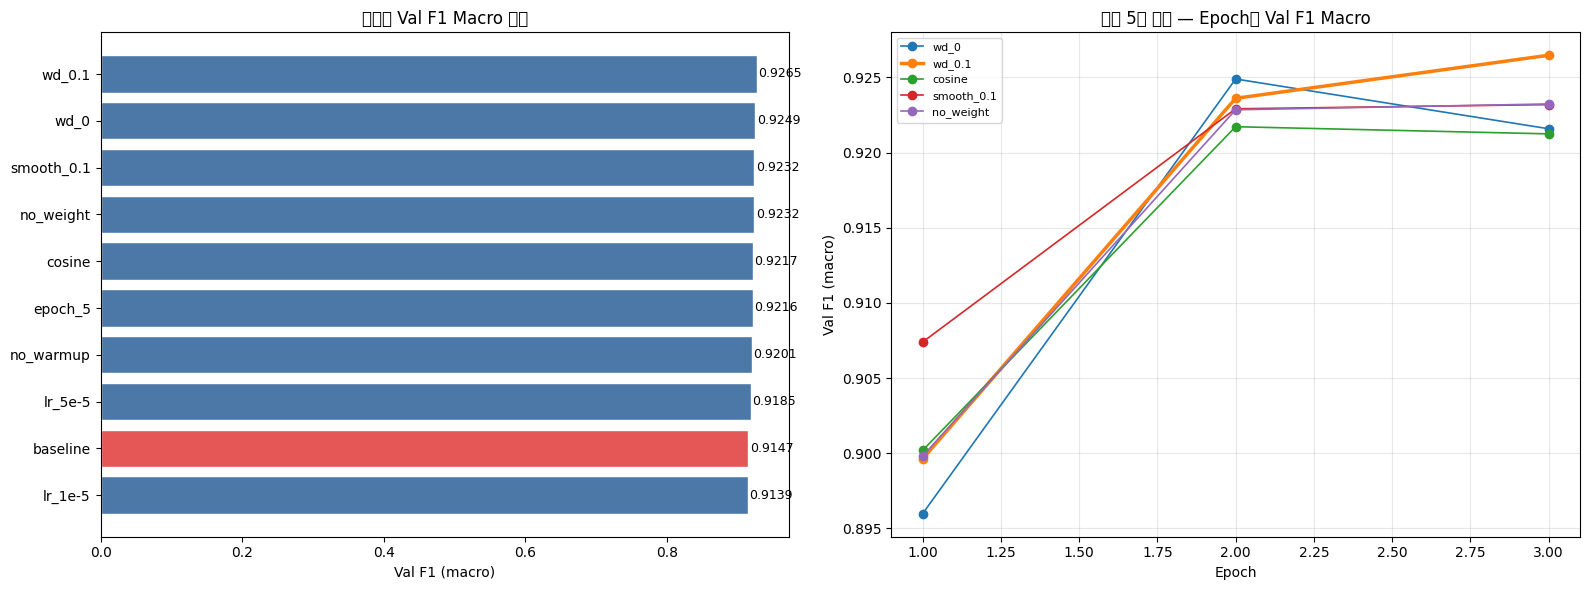

  → 저장: dktc_hp_experiment_chart.png


In [13]:
# ============================================================================
# 05. 시각화
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
 
# --- 한글 폰트 ---
font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
]
font_path = None
for fc in font_candidates:
    if os.path.exists(fc):
        font_path = fc
        break
if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
 
# --- (a) 실험별 Val F1 Macro 비교 바 차트 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
ax = axes[0]
colors = ["#E45756" if r["exp_name"] == "baseline" else "#4C78A8" for r in all_results]
sorted_results = sorted(all_results, key=lambda x: x["val_f1_macro"], reverse=True)
names = [r["exp_name"] for r in sorted_results]
f1s = [r["val_f1_macro"] for r in sorted_results]
bar_colors = ["#E45756" if n == "baseline" else "#4C78A8" for n in names]
 
ax.barh(names, f1s, color=bar_colors, edgecolor="white")
ax.set_xlabel("Val F1 (macro)")
ax.set_title("실험별 Val F1 Macro 비교")
ax.invert_yaxis()
for i, v in enumerate(f1s):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
 
# --- (b) Epoch별 학습 곡선 (상위 5개) ---
ax = axes[1]
top5 = [r["exp_name"] for r in sorted_results[:5]]
for exp_name, logs in all_epoch_logs.items():
    if not logs or exp_name not in top5:
        continue
    epochs = [l["epoch"] for l in logs]
    f1_vals = [l["eval_f1_macro"] for l in logs]
    lw = 2.5 if exp_name == sorted_results[0]["exp_name"] else 1.2
    ax.plot(epochs, f1_vals, marker="o", label=exp_name, linewidth=lw)
 
ax.set_xlabel("Epoch")
ax.set_ylabel("Val F1 (macro)")
ax.set_title("상위 5개 실험 — Epoch별 Val F1 Macro")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("dktc_hp_experiment_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → 저장: dktc_hp_experiment_chart.png")

In [14]:
# ============================================================================
# 06. Best 모델 상세 분석 (classification_report)
# ============================================================================
best_name = df_sorted.iloc[0]["exp_name"]
best_preds = all_val_preds[best_name]
best_f1 = df_sorted.iloc[0]["val_f1_macro"]
 
print(f"Best 모델: {best_name} (Val F1 Macro: {best_f1:.4f})")
print("=" * 70)
print(classification_report(
    all_val_labels,
    best_preds,
    target_names=LABEL_NAMES,
    digits=4
))
 
# 오분류 패턴 분석
from collections import Counter
wrong_mask = best_preds != all_val_labels
if wrong_mask.sum() > 0:
    print(f"\n오분류 건수: {wrong_mask.sum()} / {len(all_val_labels)} ({wrong_mask.mean()*100:.1f}%)")
    print("\n오분류 패턴 (실제→예측):")
    wrong_pairs = list(zip(all_val_labels[wrong_mask], best_preds[wrong_mask]))
    for (true_cls, pred_cls), cnt in Counter(wrong_pairs).most_common(10):
        print(f"  {LABEL_NAMES[true_cls]:10s} → {LABEL_NAMES[pred_cls]:10s}: {cnt}건")

Best 모델: wd_0.1 (Val F1 Macro: 0.9265)
              precision    recall  f1-score   support

          협박     0.9172    0.8708    0.8934       178
          갈취     0.8856    0.9128    0.8990       195
      직장내괴롭힘     0.9786    0.9433    0.9606       194
       기타괴롭힘     0.8645    0.9158    0.8894       202
        일반대화     0.9949    0.9850    0.9899       200

    accuracy                         0.9267       969
   macro avg     0.9282    0.9255    0.9265       969
weighted avg     0.9282    0.9267    0.9271       969


오분류 건수: 71 / 969 (7.3%)

오분류 패턴 (실제→예측):
  협박         → 기타괴롭힘     : 12건
  기타괴롭힘      → 갈취        : 11건
  협박         → 갈취        : 10건
  갈취         → 협박        : 9건
  직장내괴롭힘     → 기타괴롭힘     : 9건
  갈취         → 기타괴롭힘     : 7건
  기타괴롭힘      → 협박        : 5건
  직장내괴롭힘     → 갈취        : 2건
  일반대화       → 직장내괴롭힘    : 2건
  일반대화       → 기타괴롭힘     : 1건


In [15]:
# ============================================================================
# 07. 결과 저장
# ============================================================================
# CSV 저장
df_final = pd.DataFrame(all_results)
df_final.to_csv("dktc_hp_experiment_results.csv", index=False)
 
# Epoch 히스토리 JSON 저장
with open("dktc_hp_epoch_logs.json", "w") as f:
    json.dump(all_epoch_logs, f, indent=2)
 
print("dktc_hp_experiment_results.csv 저장 완료")
print("dktc_hp_epoch_logs.json 저장 완료")
print(f"\n총 실험 수: {len(all_results)}")
print(f"총 소요 시간: {df_final['train_time_sec'].sum():.0f}초 ({df_final['train_time_sec'].sum()/60:.1f}분)")
print(f"\nBest: {best_name} → Val F1 Macro: {best_f1:.4f}")

dktc_hp_experiment_results.csv 저장 완료
dktc_hp_epoch_logs.json 저장 완료

총 실험 수: 10
총 소요 시간: 1244초 (20.7분)

Best: wd_0.1 → Val F1 Macro: 0.9265
